# Visualização dos dados

> **Autor**: Miguel Vieira Machado Pim  
> **Contexto**: Desafio do processo seletivo de estágio IndustriALL

Notebooks anteriores a este:

1. [`01_pre_processing`](01_pre_processing.ipynb)

## Bibliotecas

In [1]:
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

## Funções

In [2]:
def preprocess_data(data_path: Path) -> pd.DataFrame:
    """
    Essa função coleta todos os 53 arquivos csv e converte eles em um único dataframe final.

    Args:
        data_path (Path): Caminho para a pasta que contém os arquivos csv.

    Returns:
        pd.DataFrame: Dataframe final contendo todas as features e a coluna target.
    """
    # Coletando todos os arquivos
    feature_dfs = []
    target_df = None

    for file in data_path.glob("*.csv"):
        if "target" in file.name:
            target_df = pd.read_csv(file)
            target_df.columns = ["timestamp", "target"]
        else:
            sensor_id = int(re.search(r"\d+", file.stem).group())
            
            df = pd.read_csv(file)
            df.columns = ["timestamp", f"sensor_{sensor_id}"]

            feature_dfs.append(df)
    
    feature_dfs.sort(
        key=lambda df: int(df.columns[1].split("_")[1])
    )
    
    # Tratando tipos dos datasets
    for df in feature_dfs:
        df["timestamp"] = pd.to_datetime(df["timestamp"])
    
    target_df["target"] = target_df["target"].map({
        "NORMAL": 0,
        "ANORMAL": 1
    }).astype(int)
    target_df["timestamp"] = pd.to_datetime(target_df["timestamp"])
    
    # Construindo dataset final
    df_final = (
        pd.concat(
            [target_df.set_index("timestamp")] +
            [df.set_index("timestamp") for df in feature_dfs],
            axis=1,
            join="outer" # Para mantermos timestamps que não estão em todas as tabelas
        )
        .sort_index()
    )
    
    return df_final

## Carregando os dados

In [3]:
data_path = Path("../data")

industry_df = preprocess_data(data_path)
industry_df

,target,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,...,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-04-01 00:00:00,0,4.548754,90.886874,58.698896,89.301134,1011.733181,97.284889,33.248746,-10.390227,29.262578,...,101.547023,154.291476,114.466107,103.082616,119.246973,60.729332,310.022461,124.735196,426.651658,410.820484
2018-04-01 00:01:00,0,7.887998,56.555373,80.802810,120.898222,1358.466600,202.583688,32.494870,19.427739,61.038519,...,71.846296,59.239207,90.076161,93.760055,63.457947,62.910653,306.084796,158.822485,375.316113,143.620728
2018-04-01 00:02:00,0,4.975919,182.086958,87.273632,9.914782,1056.489015,147.098428,36.402837,38.900027,30.304666,...,59.174616,87.136301,99.274584,111.916792,60.560834,81.332910,353.863854,88.772027,444.809188,618.898000
2018-04-01 00:03:00,0,6.304142,58.417235,75.059520,64.167463,1619.924847,307.722320,34.283344,46.602862,44.859311,...,0.674927,110.321579,103.978381,103.705604,24.141894,36.219671,301.563110,53.387484,414.052496,427.323378
2018-04-01 00:04:00,0,1.671733,108.946809,94.910470,14.551922,591.648283,-7.684779,30.980682,39.293311,1.229287,...,71.785623,112.435498,103.170425,110.566095,53.913605,116.770552,298.957820,168.746952,431.548430,514.659884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-31 23:55:00,0,6.066461,128.157145,144.452803,66.621842,1791.181163,172.833101,13.116142,52.438915,32.694638,...,77.001917,105.953758,169.203415,74.959180,159.206995,98.736928,432.326663,199.902569,NaN,343.198701
2018-08-31 23:56:00,0,4.057784,-31.186502,49.775117,69.397205,1166.424000,146.161645,26.785100,17.436183,39.612008,...,32.268873,12.201309,59.127149,149.304241,26.936970,125.800942,402.294815,218.904951,NaN,381.082811
2018-08-31 23:57:00,0,6.751912,80.433446,107.038506,137.923928,1060.918628,106.901675,37.495990,20.406074,33.073722,...,87.497962,90.664739,144.615688,29.140853,118.974814,75.747273,269.339456,260.899365,NaN,452.482461


## Visualizando dados temporais

In [4]:
timestamps = pd.to_datetime(industry_df.index)

inicio = timestamps.min()
fim = timestamps.max()
duracao = fim - inicio

print(f"Início: {inicio}")
print(f"Fim: {fim}")
print(f"Duração: {duracao}")
print(f"Total em dias: {duracao.total_seconds() / 86_400:.2f}")
print(f"Total em horas: {duracao.total_seconds() / 3_600:.2f}")
print(f"Quantidade de observações: {timestamps.nunique():,}")

Início: 2018-04-01 00:00:00
Fim: 2018-08-31 23:59:00
Duração: 152 days 23:59:00
Total em dias: 153.00
Total em horas: 3671.98
Quantidade de observações: 220,320


## Visualizando distribuição das classes

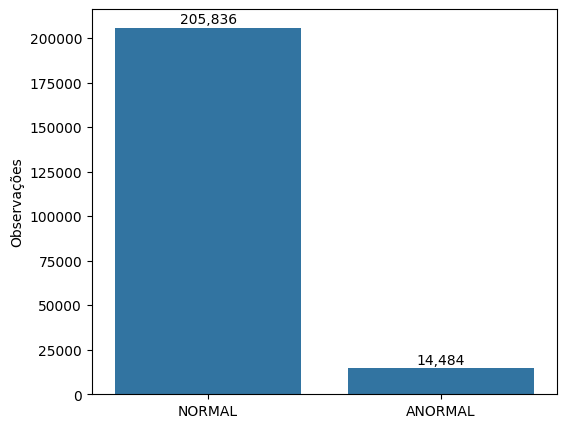

In [5]:
counts = industry_df["target"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 5))

sns.barplot(x=["NORMAL", "ANORMAL"], y=counts, ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=1)

plt.ylabel("Observações")
plt.show()

In [6]:
percentuais = industry_df["target"].value_counts(normalize=True).sort_index().mul(100).round(2)

for classe, percentual in percentuais.items():
    nome = "NORMAL" if classe == 0 else "ANORMAL"
    print(f"{nome}: {percentual:.2f}%")

NORMAL: 93.43%
ANORMAL: 6.57%


Com essas informações podemos ver que o dataset é bem **desbalanceado**.

Podemos também ter uma visualização do estado da máquina. Momentos em que houve falha e momentos em que ela estava funcionando normalmente ao longo do tempo.

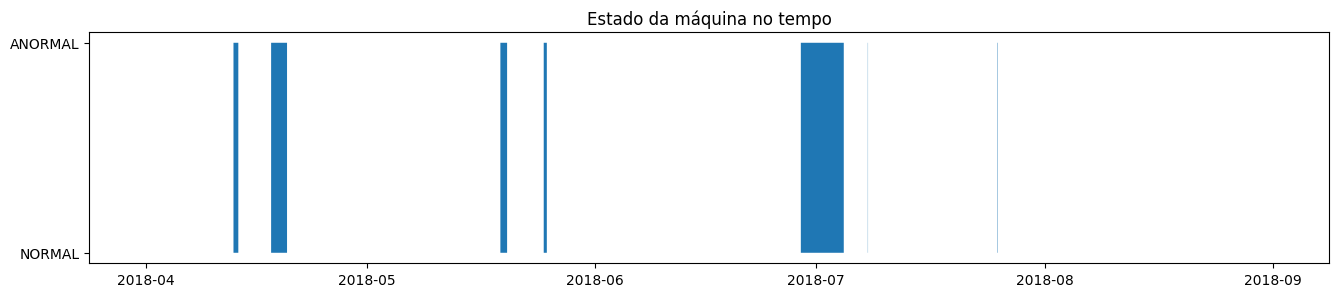

In [7]:
plt.figure(figsize=(16, 3))
plt.fill_between(industry_df.index, 0, industry_df["target"], step="post")

plt.yticks([0, 1], ["NORMAL", "ANORMAL"])
plt.title("Estado da máquina no tempo")
plt.show()

## Visualizando os sensores

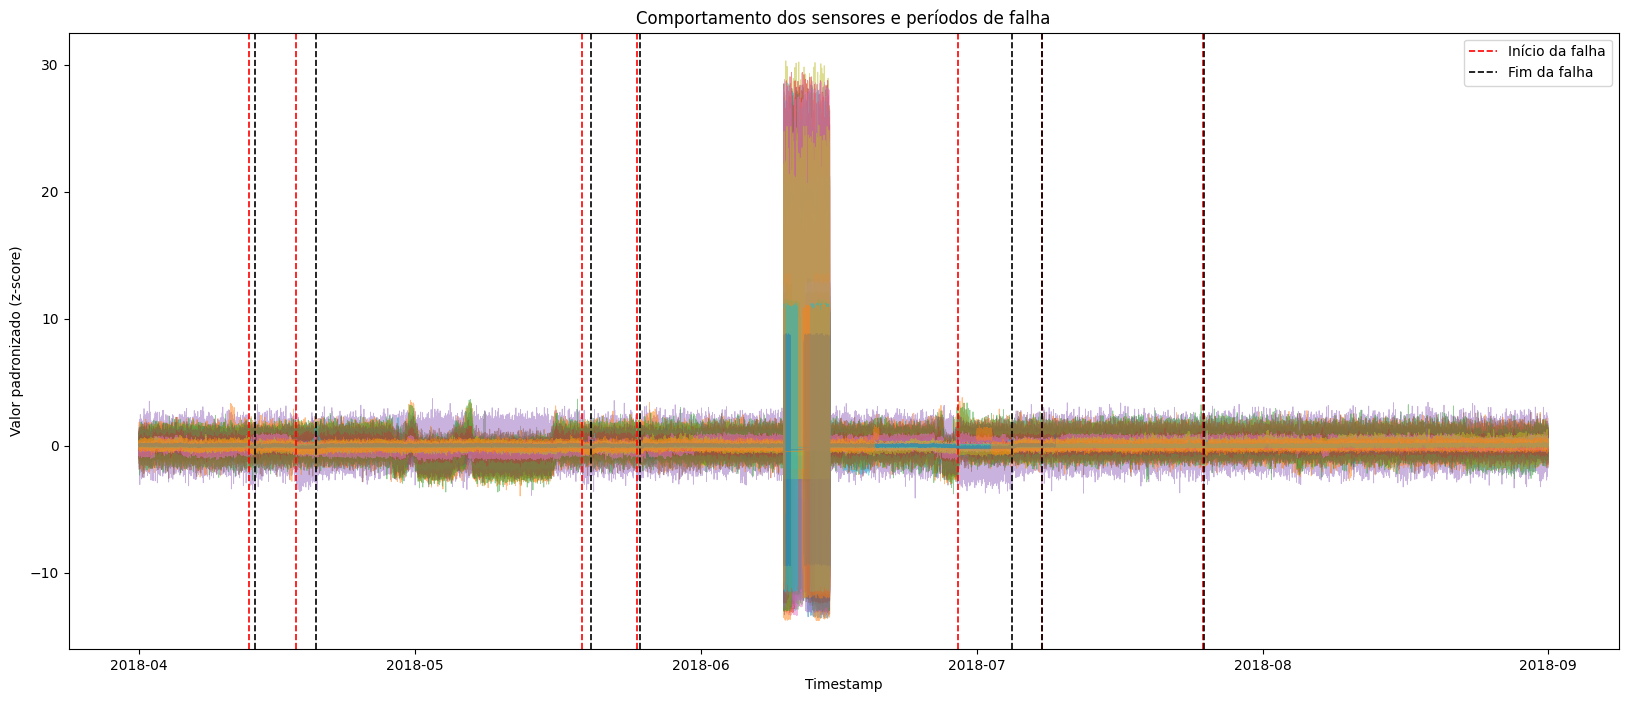

In [8]:
sensor_cols = [f"sensor_{i}" for i in range(52)]

sensors_z = (
    industry_df[sensor_cols] - industry_df[sensor_cols].mean()
) / industry_df[sensor_cols].std()

target = industry_df["target"]

inicios = industry_df.index[target.eq(1) & target.shift(fill_value=0).eq(0)]
finais = industry_df.index[target.eq(1) & target.shift(-1, fill_value=0).eq(0)]

fig, ax = plt.subplots(figsize=(20, 8))

ax.plot(
    sensors_z.index,
    sensors_z,
    linewidth=0.6,
    alpha=0.5
)

for i, inicio in enumerate(inicios):
    ax.axvline(
        inicio,
        linestyle="--",
        linewidth=1.2,
        color="red",
        label="Início da falha" if i == 0 else None
    )

for i, final in enumerate(finais):
    ax.axvline(
        final,
        linestyle="--",
        linewidth=1.2,
        color="black",
        label="Fim da falha" if i == 0 else None
    )

ax.set_title("Comportamento dos sensores e períodos de falha")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Valor padronizado (z-score)")
ax.legend()

plt.show()

O objetivo deste gráfico é apenas ter uma visualização inicial do comportamento de todos os sensores juntos. Mas, a partir dele, podemos observar que há uma anomalidade muito evidente bem no meio do período de tempo dos dados.

Nos próximos notebooks iremos investigar melhor o comportamento dos sensores.